<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Assignment_14:Ethical AI Analysis and Explainability**



**Objective**

The objective of this assignment is to develop and evaluate a machine learning model with a focus on fairness, transparency, and explainability. It aims to assess the ability to create models that are ethical, unbiased, and transparent.

 **Source of data**

 The Adult Income dataset (Dua & Graff, UCI ML Repository, 1996) contains US Census Bureau data.  



**Prediction task**

 knowing whether a person earn more than \$50 K per year or not?*


**importing necessary libraries**

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay)


In [6]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate,
    count)


**loading the data set**

In [7]:
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame
df.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


PreProcessing

checking the missing values.

In [10]:
df.shape

(48842, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [11]:
df.replace('?', np.nan, inplace=True)

In [12]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


here i will encode the target feature  as binary greater 50k and less than 50 k

In [16]:
df['income'] = (df['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)
df.drop(columns=['class'], inplace=True)

**Indentify senstitive**

In [17]:
SENSITIVE = 'sex'
print(f"\nSensitive attribute: '{SENSITIVE}'")
print(df[SENSITIVE].value_counts())


Sensitive attribute: 'sex'
sex
Male      30527
Female    14695
Name: count, dtype: int64


here there are more number of males than females this shows inbalance

**Select features**


In [18]:

NUMERIC_FEATURES = ['age', 'education-num', 'hours-per-week',
                    'capital-gain', 'capital-loss']
CATEGORICAL_FEATURES = ['workclass', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']

**Encoding the categorical_features**

In [19]:
le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    df[col] = le.fit_transform(df[col].astype(str))
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[FEATURE_COLS]
y = df['income']
A = df[SENSITIVE]

In [20]:
print(f'\nFeature matrix X shape : {X.shape}')
print(f'Target vector y shape  : {y.shape}')
print(f'Class balance (%):\n{y.value_counts(normalize=True).mul(100).round(1)}')


Feature matrix X shape : (45222, 12)
Target vector y shape  : (45222,)
Class balance (%):
income
0    75.2
1    24.8
Name: proportion, dtype: float64


**Data distribution**

Text(0, 0.5, 'Count')

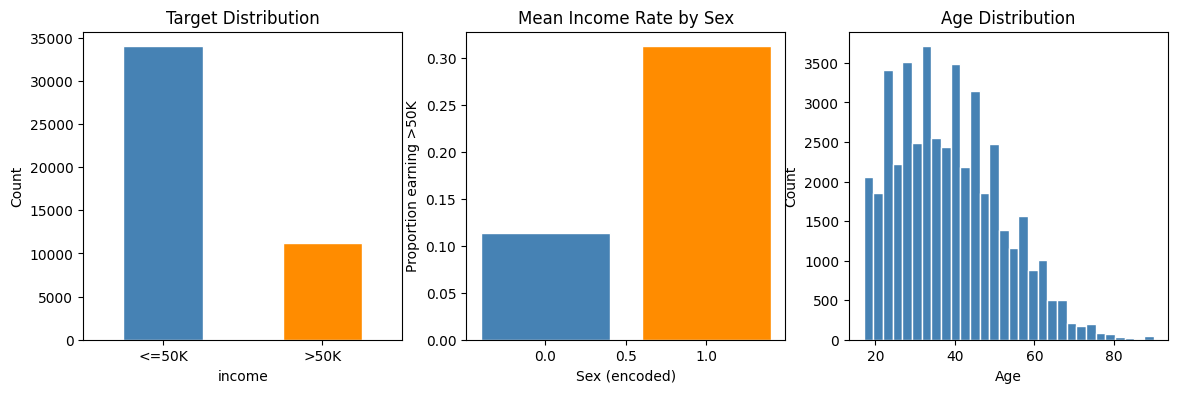

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

#  Class distribution
y.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'],
                      edgecolor='white')
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)
axes[0].set_ylabel('Count')

#  Income by sex (sensitive attribute)
sex_income = df.groupby(SENSITIVE)['income'].mean().reset_index()
axes[1].bar(sex_income[SENSITIVE], sex_income['income'],
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Mean Income Rate by Sex')
axes[1].set_xlabel('Sex (encoded)')
axes[1].set_ylabel('Proportion earning >50K')

#  Age distribution
axes[2].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

most of customers income less than or equal to 50k . out of all costomers number of  males are way greater than females .. age distribution is evenly distributed

**Model Training and Evaluation**

**Splitting the data set**

In [24]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, A,
    test_size=0.25,random_state=RANDOM_STATE,stratify=y )

print(f'Training samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')
print(f'\nTest class balance:\n{y_test.value_counts(normalize=True).mul(100).round(1)}')

Training samples : 33,916
Testing  samples : 11,306

Test class balance:
income
0    75.2
1    24.8
Name: proportion, dtype: float64



A StandardScaler is applied inside a pipeline so feature scales do not bias the gradient solver.

**Model**

LogisticRegression is chosen since the target feature(income) is binary

In [25]:
pipeline = Pipeline([('scaler', StandardScaler()),
    ('clf',    LogisticRegression( max_iter=1000,solver='lbfgs', random_state=RANDOM_STATE))])

pipeline.fit(X_train, y_train)
print('Model trained.')

Model trained.


**Prediction and overall performance**

In [26]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Overall Test Accuracy: 0.8197 (81.97%)

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      8504
        >50K       0.72      0.45      0.55      2802

    accuracy                           0.82     11306
   macro avg       0.78      0.69      0.72     11306
weighted avg       0.81      0.82      0.80     11306



The model correctly classify approximately 82 out of every 100 individuals in the test dataset.(accuracy of 81.97%) and performs well identifying individuals income less than 50k(recall 0.94).

**Confusion matrix**

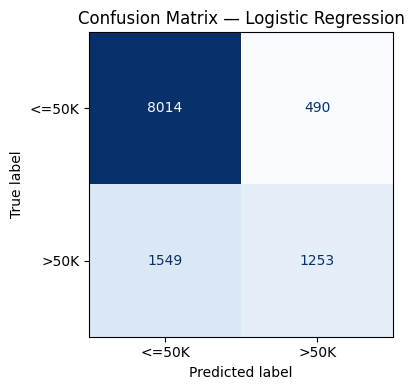

TN=8014  FP=490  FN=1549  TP=1253
False Positive Rate (overall): 0.0576
True  Positive Rate (overall): 0.4472


In [27]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'False Positive Rate (overall): {fp / (fp + tn):.4f}')
print(f'True  Positive Rate (overall): {tp / (tp + fn):.4f}')

TN=8,014: The model correctly predicted 8,014 individuals who earn 50K or less.

FP=490- incorrectly predicted 490 individuals as earning more than 50K when they actually earn 50K or less.

FN=1549- incorrectly classified 1,549 individuals who actually earn more than 50K as earning 50K or less.

TP=1253-correctly identified 1,253 individuals who earn more than 50K.

**Build MetricFrame**

Define the metrics of dictionary

In [28]:
metrics_dict = {
    'accuracy'           : accuracy_score,
    'selection_rate'     : selection_rate,
    'true_positive_rate' : true_positive_rate,
    'false_positive_rate': false_positive_rate,
    'count'              : count,}

mf = MetricFrame(
    metrics         = metrics_dict,
    y_true          = y_test,
    y_pred          = y_pred,
    sensitive_features = A_test)

print('overall metrics')
print(mf.overall)

print('metrics group by sex')
print(mf.by_group)

overall metrics
accuracy                   0.819653
selection_rate             0.154166
true_positive_rate         0.447181
false_positive_rate        0.057620
count                  11306.000000
dtype: float64
metrics group by sex
     accuracy  selection_rate  true_positive_rate  false_positive_rate   count
sex                                                                           
0    0.890519        0.036946            0.205298             0.013321  3681.0
1    0.785443        0.210754            0.493827             0.084723  7625.0



The model achieved an accuracy of 89.05% for male(0)and 78.54% for female(1).

 this indicates that the model performs more accurately for individuals in the male group

the fairness analysis indicates that the model does not perform equally across the two sex groups. significant differences are observed in selection rate, true positive rate, and false positive rate.

**Fairness Gaps**

the difference between majority class and minor class.

In [29]:

print('Fairness Gaps (difference between majority class and minor class)')
diff = mf.difference(method='between_groups')
print(diff.drop('count').round(4))

print('\n=== Fairness Ratios (minority class and majority class')
ratio = mf.ratio(method='between_groups')
print(ratio.drop('count').round(4))


Fairness Gaps (difference between majority class and minor class)
accuracy               0.1051
selection_rate         0.1738
true_positive_rate     0.2885
false_positive_rate    0.0714
dtype: float64

=== Fairness Ratios (minority class and majority class
accuracy               0.8820
selection_rate         0.1753
true_positive_rate     0.4157
false_positive_rate    0.1572
dtype: float64


Overall, the fairness results show that the model does not treat the two sex groups equally. The differences can be seen in the fairness gaps, with an accuracy gap of 10.51%, a selection rate gap of 17.38%, a true positive rate gap of 28.85%, and a false positive rate gap of 7.14%. The fairness ratios are also far from the ideal value of 1.0, especially the selection rate ratio (0.1753) and true positive rate ratio (0.4157), which show that the model’s predictions and ability to identify positive cases vary significantly between the two groups. These results suggest that the model may have some bias and does not provide the same level of performance for both groups

**summary of matrics**

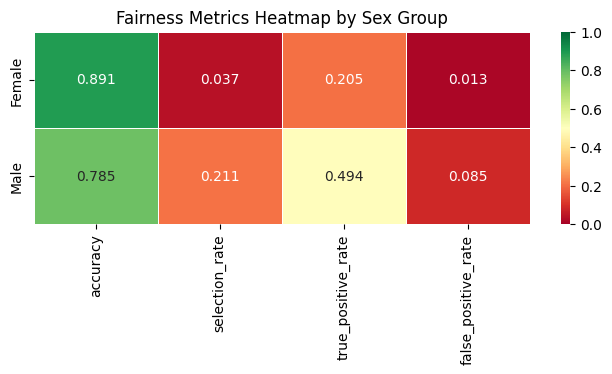

In [33]:

metrics_to_plot = ['accuracy', 'selection_rate', 'true_positive_rate', 'false_positive_rate']
heat_data = mf.by_group[metrics_to_plot].copy()
heat_data.index = ['Female', 'Male']

fig, ax = plt.subplots(figsize=(8, 2.5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Fairness Metrics Heatmap by Sex Group')
plt.show()


Fairness values range from 0 to 1 , where values closer to 1 indicate better fairness and values closer to 0 indicate greater disparity. The true positive rate ratio of 0.4157 shows a clear difference between the two sex groups, meaning the model does not identify positive cases equally and may have fairness issues.

**Explainability Analysis**

We use two complementary techniques:

SHAP (SHapley Additive exPlanations) and LIME(Local Interpretable Model-agnostic Explanations)

SHAP (SHapley Additive exPlanations)

ranks features by their mean absolute SHAP value across all test predictions, showing both *importance* (x-axis magnitude) and *directionality* (colour).

In [35]:
import shap

# ── 5.2 Prepare scaled data for SHAP ─────────────────────────────────────────
# SHAP needs the transformed (scaled) feature matrix, not raw X.
# We extract the scaler and classifier from the Pipeline.

scaler = pipeline.named_steps['scaler']
clf    = pipeline.named_steps['clf']

X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

# Use a background summary of 200 training samples for efficiency
background = shap.sample(X_train_scaled, 200, random_state=RANDOM_STATE)

print('Computing SHAP values (KernelExplainer — may take ~1 minute)...')
explainer_shap = shap.KernelExplainer(clf.predict_proba, background)

# Explain 300 test samples
shap_values = explainer_shap.shap_values(
    X_test_scaled[:300], nsamples=100
)
print('SHAP values computed.')

Computing SHAP values (KernelExplainer — may take ~1 minute)...


  0%|          | 0/300 [00:00<?, ?it/s]

SHAP values computed.


SHAP Summary Plot — Feature Importance (Global)


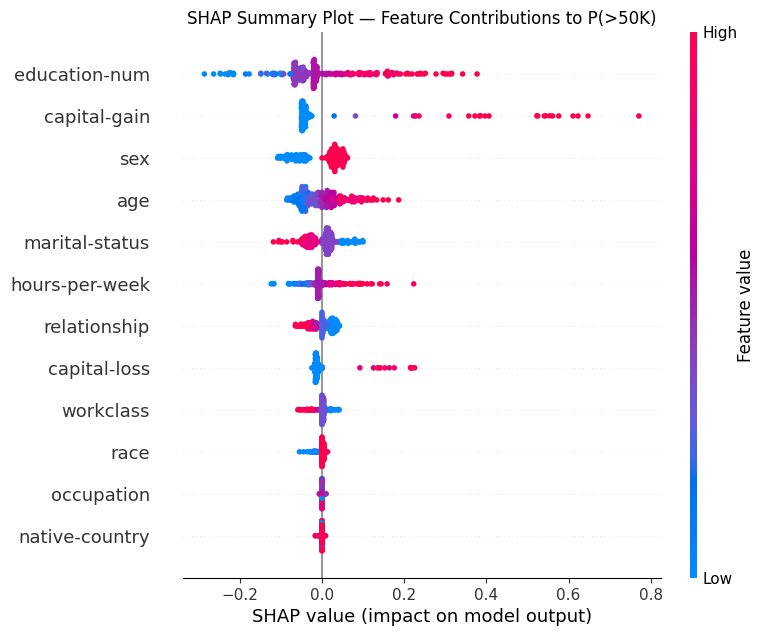

In [39]:
# ── 5.3 SHAP Summary Plot (Global) ────────────────────────────────────────────
# shap_values[:, :, 1] = SHAP values for the positive class (>50K)
print('SHAP Summary Plot — Feature Importance (Global)')
X_test_scaled_df = pd.DataFrame(X_test_scaled[:300], columns=FEATURE_COLS)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled_df,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Feature Contributions to P(>50K)')
plt.show()

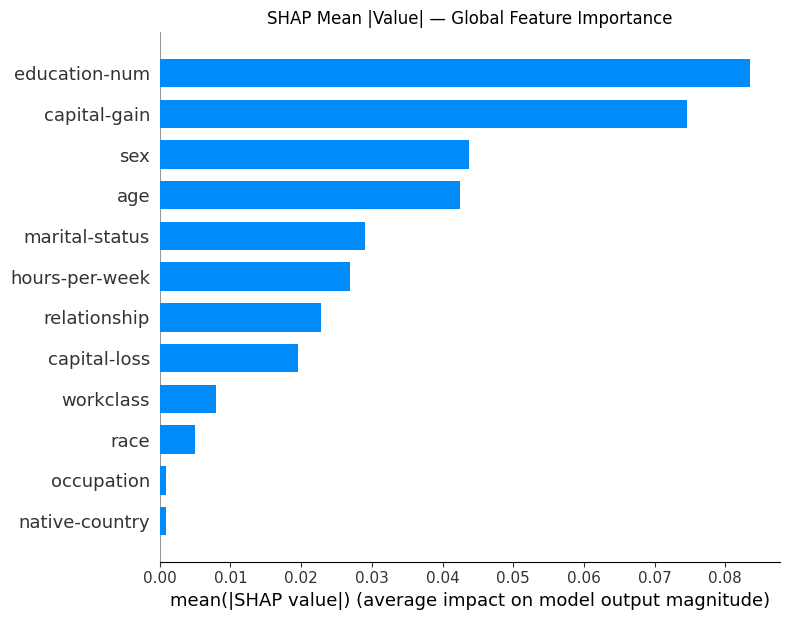

In [41]:
# ── 5.4 SHAP Bar Plot — Mean |SHAP| per feature ───────────────────────────────
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled_df,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('SHAP Mean |Value| — Global Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

**A waterfall plot**

shows how each feature pushes one individual prediction away from the base value (expected model output) toward the final prediction.  Red bars push toward >50K; blue bars push toward <=50K.

Explaining instance 0:
  True label  : 0
  Predicted   : 0
  Predict prob: 0.3215


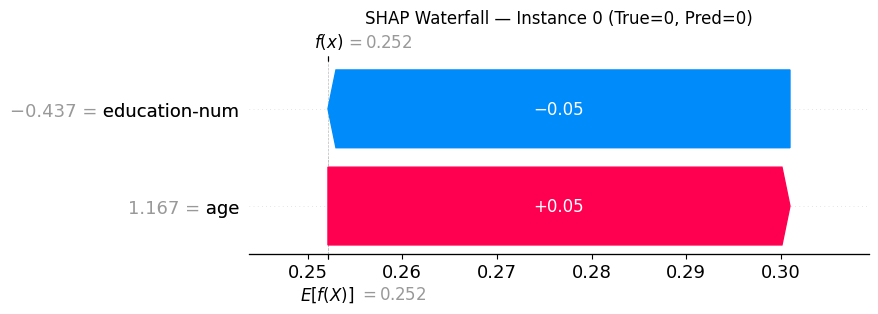

In [43]:
INSTANCE_IDX = 0

shap_exp = shap.Explanation(
    values        = shap_values[1][INSTANCE_IDX],
    base_values   = explainer_shap.expected_value[1],
    data          = X_test_scaled[INSTANCE_IDX],
    feature_names = FEATURE_COLS
)

print(f'Explaining instance {INSTANCE_IDX}:')
print(f'  True label  : {y_test.iloc[INSTANCE_IDX]}')
print(f'  Predicted   : {y_pred[INSTANCE_IDX]}')
print(f'  Predict prob: {pipeline.predict_proba(X_test.iloc[[INSTANCE_IDX]])[0][1]:.4f}')

plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Instance {INSTANCE_IDX} '
          f'(True={y_test.iloc[INSTANCE_IDX]}, Pred={y_pred[INSTANCE_IDX]})')
plt.show()

**LIME — Local Interpretable Model-agnostic Explanations**

LIME perturbs the feature values around a single instance, runs those perturbed samples through the black-box model, and fits a simple linear surrogate.  The surrogate's coefficients reveal which features most influenced *that specific prediction*.

In [47]:

from lime import lime_tabular
def predict_proba_raw(X_raw):
    """Wrap pipeline predict_proba to accept a plain numpy array."""
    return pipeline.predict_proba(pd.DataFrame(X_raw, columns=FEATURE_COLS))


lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data   = X_train.values,
    feature_names   = FEATURE_COLS,
    class_names     = ['<=50K', '>50K'],
    mode            = 'classification',
    random_state    = RANDOM_STATE)

LIME_IDX = 0
instance  = X_test.values[LIME_IDX]

lime_exp = lime_explainer.explain_instance(
    data_row         = instance,
    predict_fn       = predict_proba_raw,
    num_features     = 10,
    num_samples      = 3000
)

print(f'LIME explanation for instance {LIME_IDX}')
print(f'  True label : {y_test.iloc[LIME_IDX]}')
print(f'  Predicted  : {y_pred[LIME_IDX]}')
print('\nTop feature contributions (LIME):')
for feat, weight in lime_exp.as_list():
    direction = '▲ towards >50K' if weight > 0 else '▼ towards <=50K'
    print(f'  {feat:45s}  {weight:+.4f}  {direction}')

LIME explanation for instance 0
  True label : 0
  Predicted  : 0

Top feature contributions (LIME):
  capital-gain <= 0.00                           -0.6781  ▼ towards <=50K
  capital-loss <= 0.00                           -0.1804  ▼ towards <=50K
  education-num <= 9.00                          -0.1667  ▼ towards <=50K
  age > 47.00                                    +0.1082  ▲ towards >50K
  0.00 < sex <= 1.00                             +0.0932  ▲ towards >50K
  hours-per-week <= 40.00                        -0.0744  ▼ towards <=50K
  marital-status <= 2.00                         +0.0672  ▲ towards >50K
  native-country <= 38.00                        -0.0423  ▼ towards <=50K
  workclass <= 2.00                              +0.0272  ▲ towards >50K
  0.00 < relationship <= 1.00                    +0.0018  ▲ towards >50K
